# Lecture 5: Symmetry, Invariance, and Equivariance

The heat equation on the unit square with $u = 0$ on the walls has the 8 symmetries of the square (the group D4): rotations by 0°, 90°, 180°, 270°, and four reflections.
A model of the solution operator should be **equivariant** to them: rotating the input should rotate the prediction,

$$f(g \cdot x) = g \cdot f(x) .$$

Three parts, one for each part of today's lecture:

1. **Measure equivariance.** How far is the Lecture 4 SmallCNN from equivariant, for each element of D4 and for shifts?
2. **Group averaging.** Wrap the model so that it is exactly equivariant, and check the cost.
3. **Augmentation with little data.** Train with random D4 transformations on a single trajectory and compare with the same model trained without them.

In [1]:
import os
import time
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
rng = np.random.default_rng(0)
DATA_DIR = "../data/bubbleml"

Using device: mps


### The heat data and the model from Lecture 4

Same generator, seed and model as Lecture 4: 100 training and 20 test trajectories, each 100 steps of the exact solution on a 48 × 48 grid.
The model is SmallCNN with a standardized increment, $\hat u_{n+1} = u_n + \mu_\Delta + \sigma_\Delta f(\tilde u_n)$,
trained as in Lecture 4: MSE loss, Adam (lr $10^{-3}$), batch 64, 5 epochs over all 100 training trajectories.

In [2]:
N, alpha, dt, T, K = 48, 1.0, 5e-4, 100, 6       # same settings as Lectures 1 and 4
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)

def heat_trajectory(K=K):
    u = np.zeros((T + 1, N, N))
    t = np.arange(T + 1)[:, None, None] * dt
    for m in range(1, K + 1):
        for n in range(1, K + 1):
            a = rng.normal() / (m**2 + n**2)
            u += a * np.sin(m * np.pi * X) * np.sin(n * np.pi * Y) * np.exp(-alpha * np.pi**2 * (m**2 + n**2) * t)
    return u

heat_train = np.stack([heat_trajectory() for _ in range(100)]).astype(np.float32)
heat_test = np.stack([heat_trajectory() for _ in range(20)]).astype(np.float32)
print("train:", heat_train.shape, "  test:", heat_test.shape)

class SmallCNN(nn.Module):
    # Lecture 4 model: standardized input, output scaled to the size of the increment
    def __init__(self, stats, hidden=32, padding_mode="zeros"):
        super().__init__()
        conv = lambda i, o: nn.Conv2d(i, o, 3, padding=1, padding_mode=padding_mode)
        self.net = nn.Sequential(conv(1, hidden), nn.GELU(), conv(hidden, hidden), nn.GELU(),
                                 conv(hidden, hidden), nn.GELU(), conv(hidden, 1))
        self.mu_u, self.sigma_u, self.mu_du, self.sigma_du = stats

    def forward(self, x):
        return x + self.mu_du + self.sigma_du * self.net((x - self.mu_u) / self.sigma_u)

def increment_stats(trajs):
    # mean and std of u and of the increment u_{n+1} - u_n, from the training set (Lecture 4)
    du = trajs[:, 1:] - trajs[:, :-1]
    return [float(trajs[:, :-1].mean()), float(trajs[:, :-1].std()), float(du.mean()), float(du.std())]

def train(model, trajs, epochs=None, steps=None, augment=False, lr=1e-3, seed=0):
    # MSE on next-frame pairs; give either epochs or a number of optimizer steps.
    # augment=True: a random element of D4 (defined in Part 1) is applied to each minibatch
    torch.manual_seed(seed); np.random.seed(seed)
    pairs = TensorDataset(torch.from_numpy(trajs[:, :-1].reshape(-1, 1, N, N)),
                          torch.from_numpy(trajs[:, 1:].reshape(-1, 1, N, N)))
    loader = DataLoader(pairs, batch_size=64, shuffle=True)
    steps = steps or epochs * len(loader)
    model.to(device).train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    step, t0 = 0, time.time()
    while step < steps:
        for xb, yb in loader:
            if augment:
                g = D4[np.random.randint(8)]
                xb, yb = act(g, xb), act(g, yb)
            loss = F.mse_loss(model(xb.to(device)), yb.to(device))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            step += 1
            if step % 250 == 0 or step == steps:
                print(f"step {step:4d}/{steps}   loss {loss.item():.2e}   {time.time() - t0:.0f} s")
            if step == steps:
                break
    return model.cpu().eval()
model = train(SmallCNN(increment_stats(heat_train)), heat_train, epochs=5)

train: (100, 101, 48, 48)   test: (20, 101, 48, 48)
step  250/785   loss 1.37e-06   7 s
step  500/785   loss 1.73e-06   13 s
step  750/785   loss 1.05e-06   20 s
step  785/785   loss 8.44e-07   21 s


step  500/785   loss 2.34e-06   111 s


step  750/785   loss 9.72e-07   173 s


step  785/785   loss 1.11e-06   181 s


---
## Part 1: Measuring equivariance

The 8 elements of D4, written as $g = (k, \text{flip})$: optionally flip left-right, then rotate by $k \times 90°$.
`act(g, u)` applies $g$ to a batch of fields; `act_inv(g, u)` undoes it.

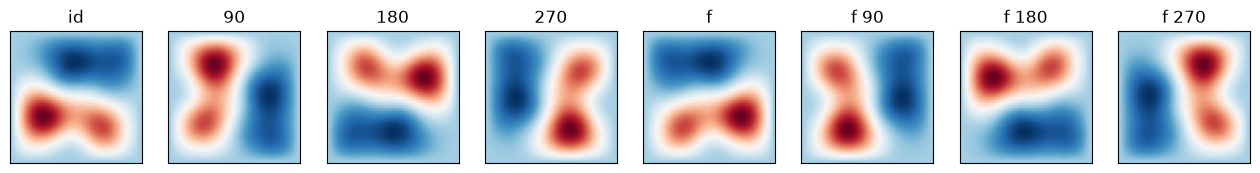

In [3]:
D4 = [(k, flip) for flip in (False, True) for k in range(4)]
NAMES = ["id", "90", "180", "270", "f", "f 90", "f 180", "f 270"]   # f: flip left-right, then rotate

def act(g, u):
    k, flip = g
    if flip:
        u = torch.flip(u, dims=(-1,))
    return torch.rot90(u, k, dims=(-2, -1))

def act_inv(g, u):
    k, flip = g
    u = torch.rot90(u, -k, dims=(-2, -1))
    if flip:
        u = torch.flip(u, dims=(-1,))
    return u

# show the 8 transformed copies of one test frame
u0 = torch.from_numpy(heat_test[0, 10]).reshape(1, 1, N, N)
fig, axes = plt.subplots(1, 8, figsize=(16, 2.4))
for ax, g, name in zip(axes, D4, NAMES):
    ax.imshow(act(g, u0)[0, 0], origin="lower", cmap="RdBu_r")
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
plt.show()

The **equivariance error** for one element $g$ compares "transform, then predict" with "predict, then transform", on the test inputs:

$$\varepsilon_g = \frac{\| f(g\cdot x) - g\cdot f(x) \|}{\| f(x) \|} .$$

The model predicts the next frame, which is close to its input. So we also report the error relative to the predicted **change** $f(x) - x$, which is what the network actually computes.

In [4]:
def rel(a, b):
    return (torch.linalg.norm(a) / torch.linalg.norm(b)).item()

@torch.no_grad()
def equivariance_errors(model, trajs):
    xs = torch.from_numpy(trajs[:, :-1:5].reshape(-1, 1, N, N))      # every 5th frame of each test trajectory
    out = model(xs)
    eps_field, eps_change = [], []
    for g in D4:
        diff = model(act(g, xs)) - act(g, out)
        eps_field.append(rel(diff, out))
        eps_change.append(rel(diff, out - xs))
    return np.array(eps_field), np.array(eps_change)

eps_field, eps_change = equivariance_errors(model, heat_test)
print(f"{'g':>7s}  {'rel. to f(x)':>13s}  {'rel. to change':>15s}")
for name, a, b in zip(NAMES, eps_field, eps_change):
    print(f"{name:>7s}  {a:13.2e}  {b:15.2e}")

      g   rel. to f(x)   rel. to change
     id       0.00e+00         0.00e+00
     90       4.07e-03         1.65e-01
    180       3.65e-03         1.48e-01
    270       4.16e-03         1.69e-01
      f       3.91e-03         1.59e-01
   f 90       2.09e-03         8.48e-02
  f 180       4.08e-03         1.65e-01
  f 270       3.47e-03         1.41e-01


**What to observe**

* The identity gives exactly zero, as it must.
* Every other element gives a nonzero error. Relative to the field it looks small, because the field changes little in one step.
  Relative to the predicted change it is a sizable fraction: the model has learned the symmetry only approximately.
* The errors are similar across the 7 non-identity elements.

### Shifts: where padding breaks translation equivariance

A convolution uses the same weights at every position, so it commutes with shifts, except near the walls, where it reads padded values.
We shift the input by 6 cells (circularly, with `torch.roll`) and measure the error at each position, first with the zero padding the model was trained with,
then with the **same weights** and circular padding.

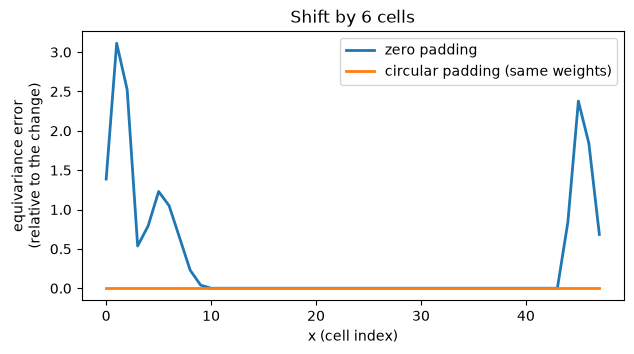

In [5]:
@torch.no_grad()
def shift_error_profile(model, trajs, s=6):
    xs = torch.from_numpy(trajs[:, :-1:5].reshape(-1, 1, N, N))
    out = model(xs)
    diff = (model(torch.roll(xs, s, dims=-1)) - torch.roll(out, s, dims=-1)).abs()
    return (diff.mean(dim=(0, 1, 2)) / (out - xs).abs().mean()).numpy()      # error at each x, relative to the change

model_circular = SmallCNN(increment_stats(heat_train), padding_mode="circular")
model_circular.load_state_dict(model.state_dict())      # same weights, circular padding
model_circular.eval()
plt.figure(figsize=(7, 3.5))
plt.plot(shift_error_profile(model, heat_test), lw=2, label="zero padding")
plt.plot(shift_error_profile(model_circular, heat_test), lw=2, label="circular padding (same weights)")
plt.xlabel("x (cell index)"); plt.ylabel("equivariance error\n(relative to the change)")
plt.title("Shift by 6 cells"); plt.legend(); plt.show()

**What to observe**

* With zero padding, the error is exactly zero in the interior and nonzero only within a few cells of the two places where the walls are: the real wall and where the shift moved it.
  Four 3 × 3 layers see 4 cells in each direction, which determines the width.
* With circular padding the same weights are exactly shift-equivariant: the padding acts like a periodic domain.
  (The model was trained with zero padding, so circular padding is the wrong boundary condition for this data. We use it here only to show where the error comes from.)

---
## Part 2: Group averaging

The model is equivariant by averaging over the group: transform the input, predict, undo the transformation, and average over all 8 elements,

$$f_G(x) = \frac{1}{|G|}\sum_{g \in G} g^{-1}\cdot f(g\cdot x) .$$

In [7]:
class GroupAveraged(nn.Module):
    def __init__(self, model, group=D4):
        super().__init__()
        self.model, self.group = model, group

    def forward(self, x):
        return torch.stack([act_inv(g, self.model(act(g, x))) for g in self.group]).mean(dim=0)

averaged = GroupAveraged(model).eval()
eps_field_avg, eps_change_avg = equivariance_errors(averaged, heat_test)
print("max equivariance error, base model:   ", f"{eps_change.max():.2e}  (relative to the change)")
print("max equivariance error, group-averaged:", f"{eps_change_avg.max():.2e}")

@torch.no_grad()
def one_step_error(model, trajs):
    xs = torch.from_numpy(trajs[:, :-1].reshape(-1, 1, N, N))
    ys = torch.from_numpy(trajs[:, 1:].reshape(-1, 1, N, N))
    return rel(model(xs) - ys, ys)

for name, m in [("base", model), ("group-averaged", averaged)]:
    t0 = time.time(); err = one_step_error(m, heat_test[:5]); t1 = time.time()
    print(f"{name:15s} one-step test error {err:.2e}   time {t1 - t0:.2f} s")

max equivariance error, base model:    1.69e-01  (relative to the change)
max equivariance error, group-averaged: 2.72e-06
base            one-step test error 6.01e-03   time 0.35 s
group-averaged  one-step test error 5.46e-03   time 2.67 s


**What to observe**

* The group-averaged model is equivariant to round-off, with no retraining.
* Its test error is lower than the base model's: averaging 8 predictions cancels errors that depend on the orientation.
* It costs about 8 times as much to evaluate: one forward pass per group element.

---
## Part 3: Augmentation with limited data

Train with **augmentation**: for each minibatch, draw a random element of D4 and apply it to both the inputs and the targets.
To make the effect visible we train on a **single** trajectory (100 training pairs), for 1000 steps, twice: without and with augmentation.
Same model, same initial weights, same data and same number of steps; only the augmentation differs.

In [10]:
one_traj = heat_train[:1]
stats1 = increment_stats(one_traj)
baseline = train(SmallCNN(stats1), one_traj, steps=1000)
augmented = train(SmallCNN(stats1), one_traj, steps=1000, augment=True)
averaged1 = GroupAveraged(baseline).eval()

step  250/1000   loss 7.30e-07   6 s
step  500/1000   loss 2.55e-07   11 s
step  750/1000   loss 1.46e-07   17 s
step 1000/1000   loss 2.35e-07   22 s
step  250/1000   loss 8.70e-07   6 s
step  500/1000   loss 4.34e-07   12 s
step  750/1000   loss 2.89e-07   18 s
step 1000/1000   loss 5.40e-07   24 s


step 1000/1000   loss 2.43e-07   152 s


step  250/1000   loss 8.70e-07   40 s


step  500/1000   loss 4.34e-07   81 s


step  750/1000   loss 2.89e-07   123 s


step 1000/1000   loss 5.02e-07   165 s


Compare the three models on the test trajectories: one-step error, equivariance error for each element, and a 100-step rollout.
During the rollout we also track the equivariance error for a 90° rotation: roll out from the rotated initial condition and compare with the rotated rollout.

no augmentation  one-step 1.06e-02   mean eq. error 9.39e-03   rollout error at step 100 0.37
D4 augmentation  one-step 1.10e-02   mean eq. error 2.56e-03   rollout error at step 100 0.46
group averaging  one-step 8.84e-03   mean eq. error 6.34e-08   rollout error at step 100 0.27


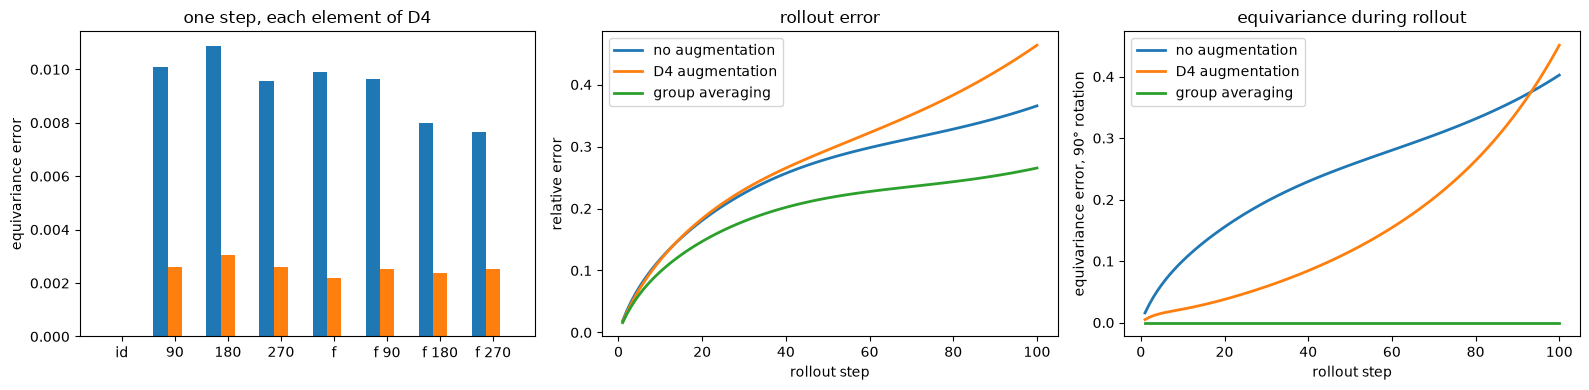

In [11]:
@torch.no_grad()
def rollout(model, u0, steps=T):
    u, out = u0, []
    for _ in range(steps):
        u = model(u); out.append(u)
    return torch.stack(out, dim=1)                       # [B, steps, 1, N, N]

@torch.no_grad()
def rollout_errors(model, trajs, g=D4[1]):
    u0 = torch.from_numpy(trajs[:, 0]).reshape(-1, 1, N, N)
    pred, pred_g = rollout(model, u0), rollout(model, act(g, u0))
    true = torch.from_numpy(trajs[:, 1:]).unsqueeze(2)
    err = [rel(pred[:, n] - true[:, n], true[:, n]) for n in range(T)]
    eq = [rel(pred_g[:, n] - act(g, pred[:, n]), pred[:, n]) for n in range(T)]
    return np.array(err), np.array(eq)

models = {"no augmentation": baseline, "D4 augmentation": augmented, "group averaging": averaged1}
results = {}
for name, m in models.items():
    eps, _ = equivariance_errors(m, heat_test)
    err, eq = rollout_errors(m, heat_test[:5])
    results[name] = dict(one_step=one_step_error(m, heat_test[:5]), eps=eps, roll=err, roll_eq=eq)
    print(f"{name:16s} one-step {results[name]['one_step']:.2e}   mean eq. error {eps[1:].mean():.2e}   rollout error at step 100 {err[-1]:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
w = 0.27
for i, (name, r) in enumerate(results.items()):
    ax[0].bar(np.arange(8) + (i - 1) * w, r["eps"], w, label=name)
    ax[1].plot(np.arange(1, T + 1), r["roll"], lw=2, label=name)
    ax[2].plot(np.arange(1, T + 1), r["roll_eq"], lw=2, label=name)
ax[0].set_xticks(range(8)); ax[0].set_xticklabels(NAMES); ax[0].set_ylabel("equivariance error"); ax[0].set_title("one step, each element of D4")
ax[1].set_xlabel("rollout step"); ax[1].set_ylabel("relative error"); ax[1].set_title("rollout error")
ax[2].set_xlabel("rollout step"); ax[2].set_ylabel("equivariance error, 90° rotation"); ax[2].set_title("equivariance during rollout")
ax[1].legend(); ax[2].legend()
plt.tight_layout(); plt.show()

**What to observe**

* **Augmentation lowers the equivariance error, but not to zero.** The model sees the symmetry only through data, so it learns it approximately.
* **Group averaging is at round-off** for every element and every rollout step.
* **Errors compound in rollout.** A small one-step equivariance error grows with every step. Augmentation slows the growth.
* **Augmentation is not free.** With the same number of training steps, the augmented model has to cover 8 times as much data.
  Its one-step and rollout errors can come out higher or lower than the baseline's, depending on the run. The lower equivariance error is the robust result.

The exact numbers change with the seed and the hyperparameters. Try `seed=1` or `steps=2000` in `train` and check which trends stay the same.

---
## Exercises

1. **Reflecting a velocity field.** BubbleML has one symmetry: left-right reflection. Load temperature, `velx` and `vely` from `Twall-106.hdf5` (Lecture 1),
   write `flip_bubbleml(T, vx, vy)` that returns the correctly reflected fields, and check it: the vorticity $\omega = \partial v_y/\partial x - \partial v_x/\partial y$
   of the reflected field should be minus the mirrored vorticity. What do you get if you forget to change the sign of `velx`? A starter cell is below.
2. **A D4-invariant kernel.** Write a 3 × 3 convolution layer whose kernel has only 3 free weights per input-output channel pair (center $m$, edges $e$, corners $c$).
   Build SmallCNN from these layers, check that it is D4-equivariant to round-off at initialization, and count its parameters. Then train it on one trajectory as in Part 3.
   How does it compare with augmentation and group averaging, and what can it not represent?
3. **The wrong symmetry (optional, longer).** Train the Lecture 1 BubbleML model (temperature, `velx`, `vely` as inputs) with augmentation by (a) the left-right reflection, done correctly,
   and (b) 90° rotations. Compare the test error on `Twall-103.hdf5`. Explain the difference.

In [9]:
# Exercise 1 starter
with h5py.File(os.path.join(DATA_DIR, "Twall-106.hdf5"), "r") as f:
    temp, velx, vely = (f[k][100].astype(np.float64) for k in ["temperature", "velx", "vely"])   # frame 100, arrays indexed (y, x)
h = 1.0   # grid spacing (any constant works for this check)

def vorticity(vx, vy):
    return np.gradient(vy, h, axis=1) - np.gradient(vx, h, axis=0)

def flip_bubbleml(T, vx, vy):
    # TODO: mirror every field left-right; which velocity component changes sign?
    raise NotImplementedError

# Tf, vxf, vyf = flip_bubbleml(temp, velx, vely)
# print(np.abs(vorticity(vxf, vyf) + vorticity(velx, vely)[:, ::-1]).max())   # should be ~0